In [ ]:
#Verifico che la GPU sia attiva
import torch
print(f"CUDA disponibile: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print( "GPU non trovata, runtimeT4 GPU")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CUDA disponibile: False
GPU non trovata, runtimeT4 GPU


In [ ]:
import os
import numpy as np #linear algebra
from google.colab import files #scaricare i miei Grafici
import matplotlib.pyplot as plt #Graph and plot
from sklearn.model_selection import train_test_split #dividere dati in gruppi
from torchvision import transforms, datasets #fondamentale per l'augmentation
from torch.utils.data import Dataset, DataLoader #fondamentale per usare dataload
from torchvision.datasets import ImageFolder #caricare immagini da cartelle
from torchvision import models #i modelli pre-addestrati poi capiamo se resnet18 o 50 e con quanti layer
import torch.nn as nn #i mattoni delle reti (Linear, Dropout, ReLU)
from PIL import Image #fondamentale per leggere jpg e png per trasformarli in indici
import kagglehub #importato senza mettere User e Password
import torch.optim as optim
import copy

In [ ]:
# Installa kagglehub
!pip install kagglehub -q #quietly

Using Colab cache for faster access to the 'garbage-classification-v2' dataset.
path to dataset files: /kaggle/input/garbage-classification-v2
Numero di Immagini 12259
Nome delle classi ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']
Totale immagini: 12259
  battery        :  756
  biological     :  699
  cardboard      : 1411
  clothes        : 1892
  glass          : 1736
  metal          :  930
  paper          : 1336
  plastic        : 1597
  shoes          : 1449
  trash          :  453


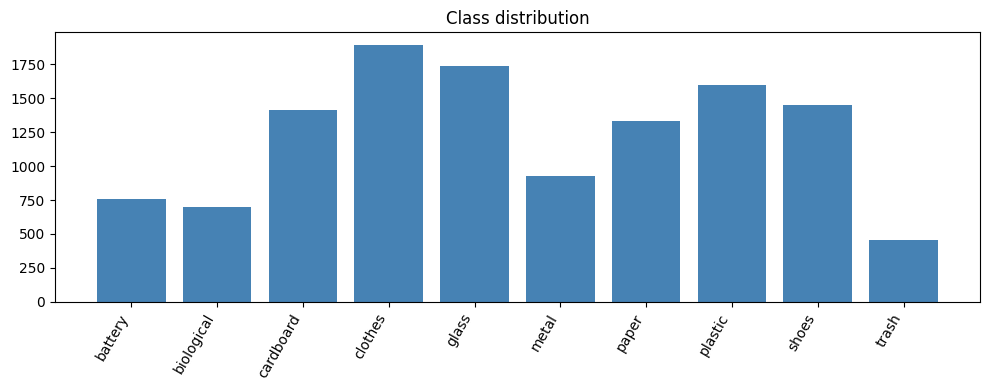

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
path = kagglehub.dataset_download("sumn2u/garbage-classification-v2")
print("path to dataset files:", path)
DATA_DIR = os.path.join(path, "standardized_256")  # uso la 256, l'idea è di usare la resnet 18 o 50 trainata su immagini da 224 pixels, vicino ai 256

full_ds = ImageFolder(DATA_DIR)

# Conteggio immagini per classe (uso DATA_DIR e full_ds.classes per restare coerente con ImageFolder)
class_counts = {}
for cls in full_ds.classes:
    imgs = [f for f in os.listdir(os.path.join(DATA_DIR, cls))
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    class_counts[cls] = len(imgs)

print("Numero di Immagini", len(full_ds))
print("Nome delle classi", full_ds.classes)

total = sum(class_counts.values())
print(f"Totale immagini: {total}")
for cls, cnt in class_counts.items():
    print(f"  {cls:15s}: {cnt:4d}")

plt.figure(figsize=(10, 4))
plt.bar(class_counts.keys(), class_counts.values(), color='steelblue')
plt.title("Class distribution")
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
files.download("class_distribution.png")



In [ ]:
samples = np.array(full_ds.samples) #passo da LIST ad Array di Nummpy
print(samples)
paths = samples[:, 0] #splitto mettendo il path(percorso) di ogni immagine dentro la var paths
labels = samples[:, 1].astype(int) #qua mi tengo l'etichetta ovvero la classe a cui appartiene ogni ordinata immagine
print(labels)

train_paths, temp_paths, train_labels, temp_labels = train_test_split(paths, labels, test_size=0.2, stratify=labels, random_state=42) #uso train_test_split che mi splitta in 4 output ( 2 insiemi di path e labels).
# Stratify è fondamentale rispettando la proporzionalità della distribuzione delle etichette, random_state necessario per la riproducibilità che mi fissa sempre gli insieme togliendo la casualità.
val_paths, test_paths, val_labels, test_labels = train_test_split(temp_paths, temp_labels, test_size=0.5,stratify=temp_labels, random_state=42)



print("Training set size:", len(train_paths))
print("Validation set size:", len(val_paths))
print("Test set size:", len(test_paths))

[['/kaggle/input/garbage-classification-v2/standardized_256/battery/battery_1.jpg'
  '0']
 ['/kaggle/input/garbage-classification-v2/standardized_256/battery/battery_10.jpg'
  '0']
 ['/kaggle/input/garbage-classification-v2/standardized_256/battery/battery_100.jpg'
  '0']
 ...
 ['/kaggle/input/garbage-classification-v2/standardized_256/trash/trash_97.jpg'
  '9']
 ['/kaggle/input/garbage-classification-v2/standardized_256/trash/trash_98.jpg'
  '9']
 ['/kaggle/input/garbage-classification-v2/standardized_256/trash/trash_99.jpg'
  '9']]
[0 0 0 ... 9 9 9]
Training set size: 9807
Validation set size: 1226
Test set size: 1226


In [ ]:
train_trans = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_trans = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


In [ ]:
#Class Dataset
class Ds(Dataset):

  def __init__(self,paths,labels,transform=None):
    self.paths=paths
    self.labels=labels
    self.transform=transform

  def __len__(self):
    return len(self.paths)

  def __getitem__(self,idx):
    path=self.paths[idx]
    image=Image.open(path).convert("RGB")
    if self.transform: #cuore della classe dataset dove applico le mie transform
      image=self.transform(image)
    return image,self.labels[idx]

#TESTO le funz della classe creata
train_ds=Ds(train_paths,train_labels,train_trans)
print("dataset creato")
val_ds=Ds(val_paths,val_labels,val_trans)
test_ds=Ds(test_paths,test_labels,val_trans)
print(len(train_ds))
print(len(val_ds))
print(len(test_ds))

#TESTO l'augmentation
a, _ = train_ds[0]
b, _ = train_ds[0]
print("Stessa immagine identica?", torch.equal(a, b)) #False(augmentation varia)

c, _ = val_ds[0]
d, _ = val_ds[0]
print("Val identica?", torch.equal(c, d)) #True(nessuna augmentation)

#Preparo i batch li tengo a 32 con shuffle ovviamente solo su training set
train_dl=DataLoader(train_ds, batch_size=32, shuffle=True)
val_dl=DataLoader(val_ds, batch_size=32, shuffle=False)
test_dl=DataLoader(test_ds, batch_size=32, shuffle=False)

#Testo il batch
image, labels = next(iter(train_dl))
print(image.shape) #32 immagini, 3 canali, 224X224
print(labels.shape)

num_classes= len(full_ds.classes)
print(f"Numero di classi: {num_classes}")
print(f"Classi: {full_ds.classes}")
print(f"Batch per epoca (train): {len(train_dl)}")

dataset creato
9807
1226
1226
Stessa immagine identica? False
Val identica? True
torch.Size([32, 3, 224, 224])
torch.Size([32])
Numero di classi: 10
Classi: ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']
Batch per epoca (train): 307


In [ ]:
def build_model(num_classes=10,dropout=0.3,finetune_layer4=False): #Inizializziamo il Droput a 0.3, ogni passaggio di batch_size spengo il 30% dei neuroni
  model=models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1) #Prendo la rete pre-addesdata su ImagenNet
  for param in model.parameters():
    param.requires_grad=False #Congelo il Backcbone inizialmente così mi tengo tutti i parametri della ResNet su Imagenet
  if finetune_layer4: #Scongelo SOLO l'ultimo blocco (layer4). DOPO il freeze, altrimenti il loop sopra lo ricongela
    for param in model.layer4.parameters():
      param.requires_grad=True
  in_features = model.fc.in_features #Adesso cambio la testa, l'ultimo Layer della Resnet-18 (o 50 vediamo)perchè ha 1000 classi di base e io ne devo prendere solo 10, quindi faccio Linear(512)-> ReLu-> Dropout-> Linear(256)-> 10
  model.fc = nn.Sequential(
  nn.Dropout(p=dropout), #Dropout
  nn.Linear(in_features, 256), #in_features
  nn.ReLU(), #Activation function dell'Hidden Layer
  nn.Dropout(p=dropout/2),#dropout/2 perima dell'Output Layer
  nn.Linear(256,num_classes) )
  return model

#Testo la funzione
m = build_model()
trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
totali    = sum(p.numel() for p in m.parameters())
print(f"Addestrabili: {trainable:,} su {totali:,} ({trainable/totali*100:.1f}%)")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 45.9MB/s]


Addestrabili: 133,898 su 11,310,410 (1.2%)


In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
  model.train() #Metodo importato da Pytorch
  loss_sum, correct, total = 0.0, 0, 0
  for images, labels in loader:
        images, labels = images.to(device), labels.to(device)   #Carico tutto su GPU

        optimizer.zero_grad()          #riazzera i gradienti ogni epoch (step5) perchè aggiorno ogni volta i pesi e ricalcolo ogni epoch
        outputs = model(images)            #previsione
        loss = criterion(outputs, labels)  #Valuto gli erorri poi metterò cross-ent
        loss.backward()              #calcolo i gradienti
        optimizer.step()      #Aggiorna i pesi

        loss_sum += loss.item() * images.size(0) #Questo perchè userò la cross-entropy che mi darà l'errore medio sul batch
        correct  += (outputs.argmax(1) == labels).sum().item() #"outputs" ha due argomenti {batch,num_classe} quindi sommo quando classe = labels, .item per staccare il valore dal grafo
        total    += labels.size(0) #Numero di immagini dentro al batch

  return loss_sum / total, correct / total

def evaluate(model, loader, criterion, device):
  model.eval() #Metodo importato da Pytorch
  loss_sum, correct, total = 0.0, 0, 0
  with torch.no_grad(): #Tolgo sull'evaluation il calcolo dei gradeinti testo i pesi che ho aggiornato sul training Set
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)              #previsione
        loss = criterion(outputs, labels)    #calcola la loss (solo per misurarla)
        loss_sum += loss.item() * images.size(0) #Questo perchè userò la cross-entropy che mi darà l'errore medio sul batch
        correct  += (outputs.argmax(1) == labels).sum().item()
        total    += labels.size(0)

  return loss_sum / total, correct / total

In [ ]:
def train_model(model, train_loader, val_loader, config, device, verbose=True):
    criterion = nn.CrossEntropyLoss()

    # Ottimizzo solo i parametri addestrabili (requires_grad=True)
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=config['lr'], #Configurzione del learning-rate
        weight_decay=config['weight_decay']  #L2 regularization
    )

    #Posso mettere Scheduler? Potrebbe dimezzare il LR se val_loss non migliora per 'factor_patience' epoche
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []} #Inizializzo
    best_val_loss = float('inf')
    best_val_acc  = 0.0
    patience_counter = 0
    best_model_state = None

    for epoch in range(config['epochs']):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device) #Imposto dentro il ciclo for delle epoche i train_loss e la train_acc
        val_loss,   val_acc   = evaluate(model, val_loader, criterion, device) #Imposto la avlidation nel ciclo delle epoche

        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if verbose:
            print(f"Epoch {epoch+1:3d}/{config['epochs']} | "
                  f"Train Loss: {train_loss:.4f} Acc: {train_acc:.3f} | "
                  f"Val Loss: {val_loss:.4f} Acc: {val_acc:.3f}")

        #Early stopping e salvataggio del miglior modello
        if val_loss < best_val_loss:
            best_val_loss  = val_loss
            best_val_acc   = val_acc
            patience_counter = 0
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= config['patience']:
                if verbose:
                    print(f"Early stopping all'epoca {epoch+1} (no improvement for {config['patience']} epochs)")
                break

    #Ripristino i pesi migliori trovati
    model.load_state_dict(best_model_state)
    return history, best_val_acc


print("Funzioni di training definite.")

Funzioni di training definite.


In [ ]:
param_grid = [
    {'lr': 1e-3, 'weight_decay': 1e-4, 'dropout_rate': 0.3},
    {'lr': 1e-3, 'weight_decay': 1e-4, 'dropout_rate': 0.5}, #peggiore nei giri fi Test
    {'lr': 5e-4, 'weight_decay': 1e-4, 'dropout_rate': 0.5}, #2° preggiore nei giri di test
    {'lr': 1e-3, 'weight_decay': 1e-3, 'dropout_rate': 0.5},
]

#Configurazione training per la model selection
BASE_CONFIG = {
    'epochs':  25,
    'patience': 7,
}

print(f"Numero di configurazioni da testare: {len(param_grid)}")
print(f"Epoche max per configurazione: {BASE_CONFIG['epochs']}")
print(f"\nConfigurations:")
for i, cfg in enumerate(param_grid):
    print(f"  [{i+1}] lr={cfg['lr']}, weight_decay={cfg['weight_decay']}, dropout={cfg['dropout_rate']}")

Numero di configurazioni da testare: 4
Epoche max per configurazione: 25

Configurations:
  [1] lr=0.001, weight_decay=0.0001, dropout=0.3
  [2] lr=0.001, weight_decay=0.0001, dropout=0.5
  [3] lr=0.0005, weight_decay=0.0001, dropout=0.5
  [4] lr=0.001, weight_decay=0.001, dropout=0.5


In [ ]:
results = []

for i, params in enumerate(param_grid):
    print(f"\n{'='*60}")
    print(f"Configurazione {i+1}/{len(param_grid)}: {params}")
    print('='*60)

    #Costruiamo un modello fresco per ogni configurazione
    m = build_model(num_classes, dropout=params['dropout_rate'])
    m = m.to(device)

    config = {**BASE_CONFIG, 'lr': params['lr'], 'weight_decay': params['weight_decay']}
    history, best_val_acc = train_model(model=m, train_loader=train_dl, val_loader=val_dl, config=config, device=device, verbose=True)

    results.append({
        'params': params,
        'best_val_acc': best_val_acc,
        'history': history,
        'model': m
    })
    print(f"→ Best Val Accuracy: {best_val_acc:.4f}")

#Trovo la migliore configurazione
best_result = max(results, key=lambda x: x['best_val_acc'])
best_params = best_result['params']
best_model  = best_result['model']

print(f"\n{'='*60}")
print(f"MIGLIORI IPERPARAMETRI: {best_params}")
print(f"Best Validation Accuracy: {best_result['best_val_acc']:.4f}")
print('='*60)

#Riepilogo di tutte le configurazioni
print("\nRiepilogo model selection:")
for r in sorted(results, key=lambda x: x['best_val_acc'], reverse=True):
    print(f"  Val Acc: {r['best_val_acc']:.4f} | {r['params']}")


Configurazione 1/4: {'lr': 0.001, 'weight_decay': 0.0001, 'dropout_rate': 0.3}
Epoch   1/25 | Train Loss: 1.0154 Acc: 0.654 | Val Loss: 0.5551 Acc: 0.807
Epoch   2/25 | Train Loss: 0.7562 Acc: 0.742 | Val Loss: 0.5491 Acc: 0.814
Epoch   3/25 | Train Loss: 0.7242 Acc: 0.751 | Val Loss: 0.5213 Acc: 0.834
Epoch   4/25 | Train Loss: 0.6912 Acc: 0.758 | Val Loss: 0.4547 Acc: 0.853
Epoch   5/25 | Train Loss: 0.6585 Acc: 0.773 | Val Loss: 0.4982 Acc: 0.832
Epoch   6/25 | Train Loss: 0.6438 Acc: 0.779 | Val Loss: 0.4514 Acc: 0.852


In [ ]:


#Parto dai pesi del best model congelato (testa GIA' allenata) e sblocco solo layer4.
#dropout e weight_decay restano FISSI (quelli del best model); vario SOLO il learning rate.
base_state= copy.deepcopy(best_model.state_dict())   #testa allenata + backbone ImageNet
fixed_dropout = best_params['dropout_rate']
fixed_wd = best_params['weight_decay']

ft_lrs = [1e-3, 1e-4, 1e-5]
ft_results = []

for lr in ft_lrs:
    print(f"\n{'='*60}")
    print(f"Fine-tuning layer4 | lr={lr} | dropout={fixed_dropout} | wd={fixed_wd}")
    print('='*60)

    #Modello con layer4 sbloccato, poi RICARICO i pesi del best model (così la testa non riparte random)
    m_ft = build_model(num_classes, dropout=fixed_dropout, finetune_layer4=True)
    m_ft.load_state_dict(base_state)   #load_state_dict copia i valori, NON i requires_grad → layer4 resta sbloccato
    m_ft = m_ft.to(device)

    cfg = {**BASE_CONFIG, 'lr': lr, 'weight_decay': fixed_wd}
    history, best_val_acc = train_model(m_ft, train_dl, val_dl, cfg, device)

    ft_results.append({'lr': lr, 'best_val_acc': best_val_acc, 'history': history, 'model': m_ft})
    print(f"→ Best Val Accuracy: {best_val_acc:.4f}")

#Miglior fine-tuning
best_ft = max(ft_results, key=lambda x: x['best_val_acc'])
best_unfreeze_model = best_ft['model']

print(f"\n{'='*60}")
print(f"MIGLIOR FINE-TUNING: lr={best_ft['lr']} | Val Acc: {best_ft['best_val_acc']:.4f}")
print('='*60)
print("\nRiepilogo fine-tuning (ordinato):")
for r in sorted(ft_results, key=lambda x: x['best_val_acc'], reverse=True):
    print(f"  Val Acc: {r['best_val_acc']:.4f} | lr={r['lr']}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

#BEST MODEL dell'ablation — criterio: val_loss minima (più stabile dell'accuracy).
#Nota: ogni r['model'] ha GIA' i pesi del suo best epoch, perché train_model e ripristina con load_state_dict alla fine della run.
best = min(ft_results, key=lambda r: min(r['history']['val_loss']))
best_model = best['model'].to(device)

best_ep = int(np.argmin(best['history']['val_loss']))
print(f"Modello scelto: lr={best['lr']}")
print(f"  best epoch (val_loss minima): {best_ep + 1}")
print(f"  val_loss: {best['history']['val_loss'][best_ep]:.4f} | "
      f"val_acc: {best['history']['val_acc'][best_ep]:.4f}")

#vALUTAZIONE SUL TEST SET
criterion = nn.CrossEntropyLoss()
test_loss, test_acc = evaluate(best_model, test_dl, criterion, device)

print(f"\n{'='*50}")
print(f"  RISULTATI FINALI — TEST SET")
print(f"{'='*50}")
print(f"  Test Loss:     {test_loss:.4f}")
print(f"  Test Accuracy: {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"{'='*50}")

# Predictions complete per le metriche per-classe
best_model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for images, labels in test_dl:
        out = best_model(images.to(device))
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_true.extend(labels.numpy())

class_names = full_ds.classes

print("\nClassification Report:")
print(classification_report(all_true, all_preds, target_names=class_names, digits=3))

#Confusion matrix normalizzata (diagonale = accuratezza per classe), fuori covarianza delle due classi prese in esame se alta è alta la prob di confondere le due classi
cm = confusion_matrix(all_true, all_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt='.2f',
            xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.title("Confusion Matrix normalizzata — Test set")
plt.ylabel("Classe reale")
plt.xlabel("Classe predetta")
plt.xticks(rotation=30, ha='right'); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()